# Gitcoin Dynamical Network generation


## Dependences & parameters

In [1]:
%load_ext autotime
import plotly.io as pio
pio.renderers.default = "jupyterlab"

In [2]:
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx
import plotly.express as px
import pandas as pd
import inequality_coefficients as ineq
from tqdm.auto import tqdm

time: 2.69 s


## Load data from pickle file

In [3]:
import cloudpickle
from env_config import PICKLE_PATH

with open(PICKLE_PATH, 'rb') as fid:
    result = cloudpickle.load(fid)

time: 675 ms


## Data preparation

In [4]:
df = result.loc[(0, 0, 1, slice(None))]

time: 7.01 ms


## Data visualization

### Timeseries for total amounts, Round-wide

#### Quadratic funding

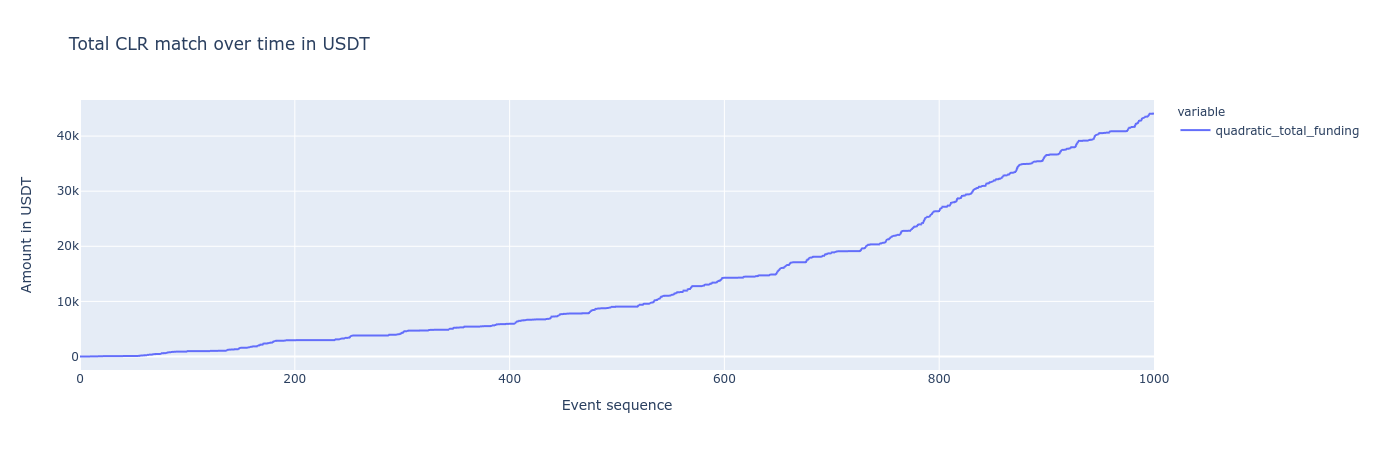

time: 588 ms


In [5]:
fig_df = df.reset_index()

title = 'Total CLR match over time in USDT'

x_col = 'timestep'
y_cols = ['quadratic_total_funding']

labels = {'value': 'Amount in USDT',
          'timestep': 'Event sequence'}

options = {'x': x_col,
           'y': y_cols,
           'title': title,
           'labels': labels}

fig = px.line(fig_df, **options)

fig.show()

#### Total donations

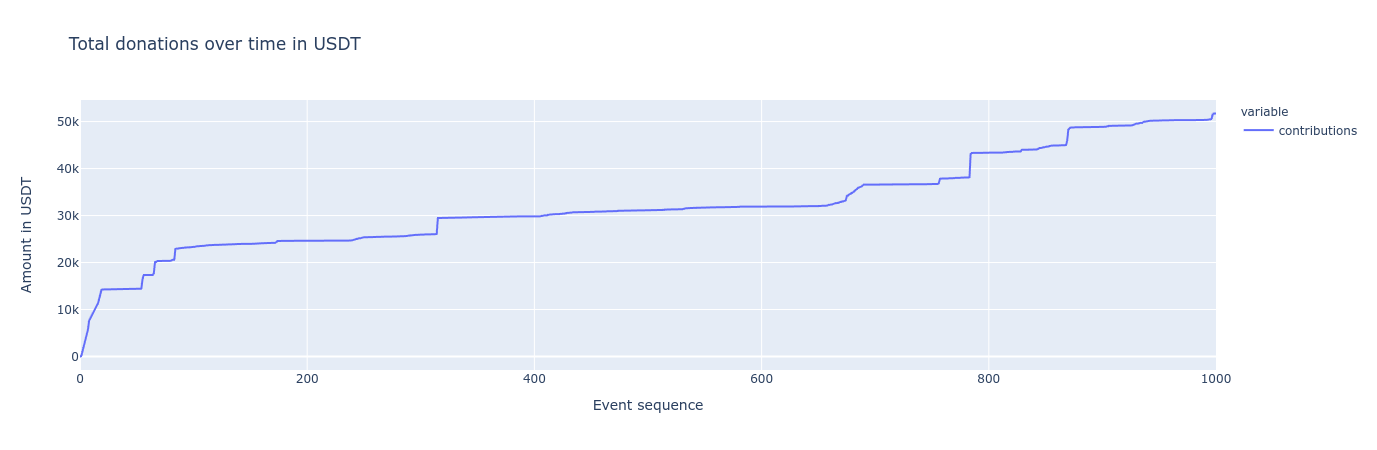

time: 226 ms


In [6]:
contribs_total_donation = lambda contribs: sum(contrib['amount'] for contrib in contribs)
contrib_per_time = df.contributions.map(contribs_total_donation)
fig_df = contrib_per_time.reset_index()

title = 'Total donations over time in USDT'

x_col = 'timestep'
y_cols = ['contributions']

labels = {'value': 'Amount in USDT',
          'timestep': 'Event sequence'}

options = {'x': x_col,
           'y': y_cols,
           'title': title,
           'labels': labels}

fig = px.line(fig_df, **options)

fig.show()

#### Gini index

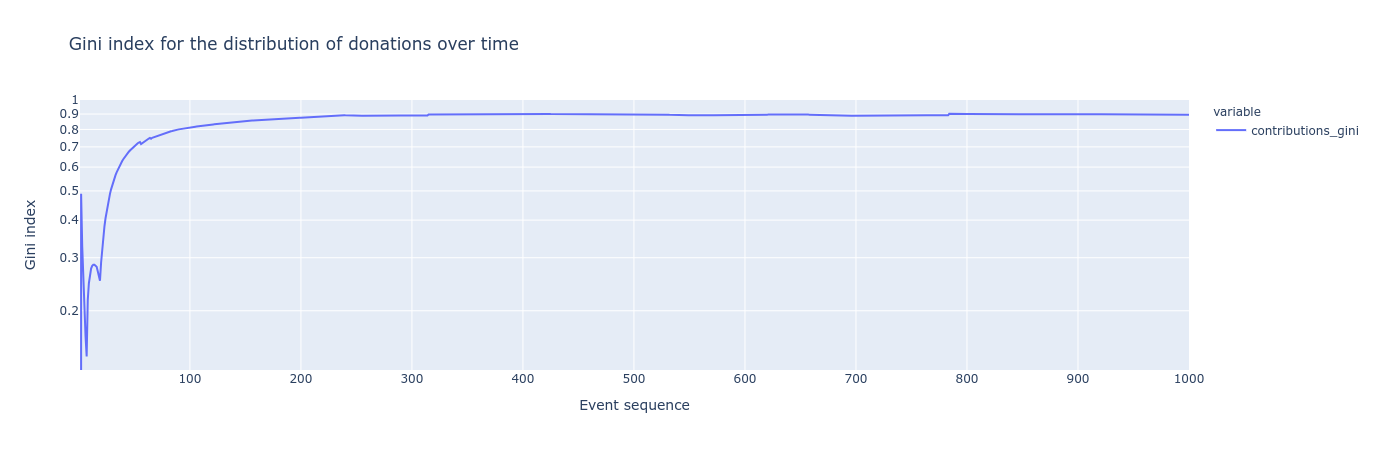

time: 1.51 s


In [7]:
contribs_total_donation = lambda contribs: ineq.gini([contrib['amount'] for contrib in contribs]) / len(contribs)
contrib_per_time = df.contributions.iloc[1:].map(contribs_total_donation)
contrib_per_time.name = 'contributions_gini'
fig_df = contrib_per_time.reset_index()

title = 'Gini index for the distribution of donations over time'

x_col = 'timestep'
y_cols = ['contributions_gini']

labels = {'value': 'Gini index',
          'timestep': 'Event sequence'}

options = {'x': x_col,
           'y': y_cols,
           'title': title,
           'labels': labels,
           'log_y': True}

fig = px.line(fig_df, **options)

fig.show()

### Time interactive bar plots for the top 15 grants

In [8]:
N = 14

grant_dataset = defaultdict(list)
for i, row in tqdm(df.iterrows(), total=len(df)):
    if i == 0:
        continue
        
    # Donations
    metric_df = pd.DataFrame(row.contributions)
    s = metric_df.groupby('grant').amount.sum().sort_values()
    top_N = s.iloc[-N:]
    remaining = s.iloc[:-N].sum()
    metrics = pd.Series({**top_N.to_dict(), 'Others': remaining}).sort_values()
    el = {**top_N.to_dict(), 'Others': remaining.sum()}
    grant_dataset['agg_top_contribs'].append(el)
    grant_dataset['agg_contribs'].append(s.to_dict())
    
    # Unique contributors
    metric_df = pd.DataFrame(row.contributions)
    s = metric_df.groupby('grant').contributor.nunique().sort_values()
    top_N = s.iloc[-N:]
    remaining_indices = ~metric_df.grant.isin(top_N.index)
    remaining = metric_df[remaining_indices].contributor.nunique()
    metrics = pd.Series({**top_N.to_dict(), 'Others': remaining}).sort_values()
    el = {**top_N.to_dict(), 'Others': remaining}
    grant_dataset['agg_top_unique'].append(el)
    grant_dataset['agg_unique'].append(s.to_dict())

    # CLR match
    obj = row.quadratic_funding_per_grant
    s = pd.Series(obj).sort_values()
    top_N = s.iloc[-N:]
    remaining = s.iloc[:-N]
    el = {**top_N.to_dict(), 'Others': remaining.sum()}
    grant_dataset['agg_top_clr_funding'].append(el)
    grant_dataset['agg_clr_funding'].append(s.to_dict())
    
    # Simple CLR match
    obj = row.simple_quadratic_funding_per_grant
    s = pd.Series(obj).sort_values()
    top_N = s.iloc[-N:]
    remaining = s.iloc[:-N]
    el = {**top_N.to_dict(), 'Others': remaining.sum()}
    grant_dataset['agg_top_simple_clr_funding'].append(el)
    grant_dataset['agg_simple_clr_funding'].append(s.to_dict())


time: 29.5 s


In [9]:
def cleanup(grant_dataset: dict, key: str) -> pd.DataFrame:
    df = (pd.DataFrame(grant_dataset[key])
            .unstack()
            .reset_index()
            .rename(columns={'level_0': 'grant',
                             'level_1': 'timestep',
                             0: key})
            .dropna())
    return df

grant_dfs = {k: cleanup(grant_dataset, k) for k in grant_dataset.keys()}

time: 895 ms


#### CLR match gini index across grants 

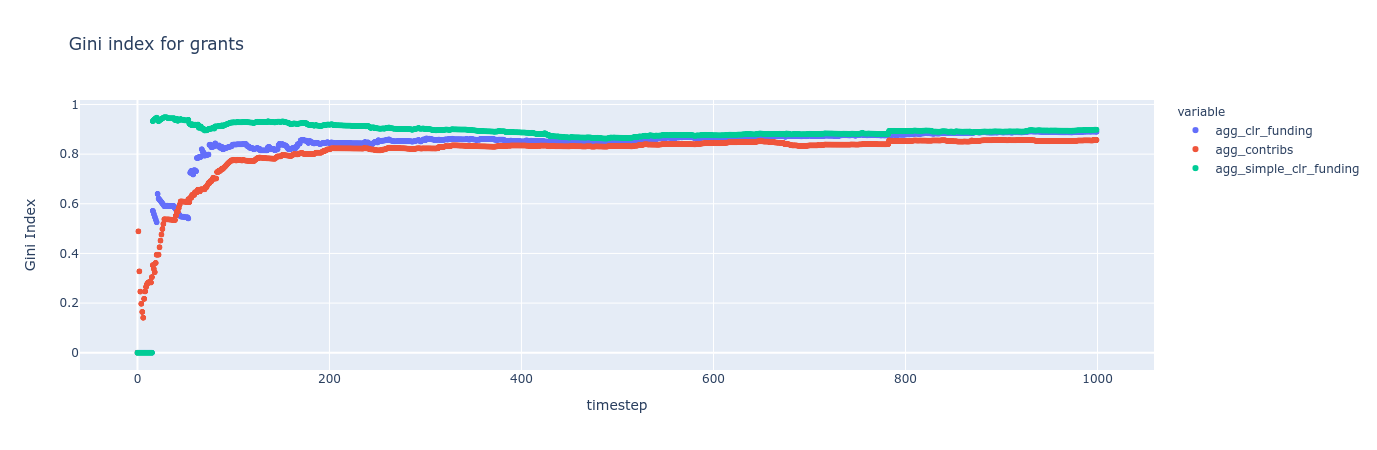

time: 1.68 s


In [10]:
key_1 = 'agg_clr_funding'
fig_df_1 = (grant_dfs[key_1]
            .sort_values(by=key_1)
            .groupby('timestep')[key_1]
            .apply(lambda s: ineq.gini(s) / len(s))
            .reset_index()
         )

key_2 = 'agg_contribs'
fig_df_2 = (grant_dfs[key_2]
            .sort_values(by=key_2)
            .groupby('timestep')[key_2]
            .apply(lambda s: ineq.gini(s) / len(s))
            .reset_index()
         )

key_3 = 'agg_simple_clr_funding'
fig_df_3 = (grant_dfs[key_3]
            .sort_values(by=key_3)
            .groupby('timestep')[key_3]
            .apply(lambda s: ineq.gini(s) / len(s))
            .reset_index()
         )

fig_df = (fig_df_1.set_index('timestep')
                  .join(fig_df_2.set_index('timestep'))
                  .join(fig_df_3.set_index('timestep'))
                  .reset_index())

title = 'Gini index for grants'

x_col = 'timestep'
y_cols = [key_1, key_2, key_3]

labels = {'value': 'Gini Index',
          'grant': ''}

options = {'x': x_col,
           'y': y_cols,
           'title': title,
           'labels': labels}

fig = px.scatter(fig_df, **options)

fig.show()

#### Grant funding

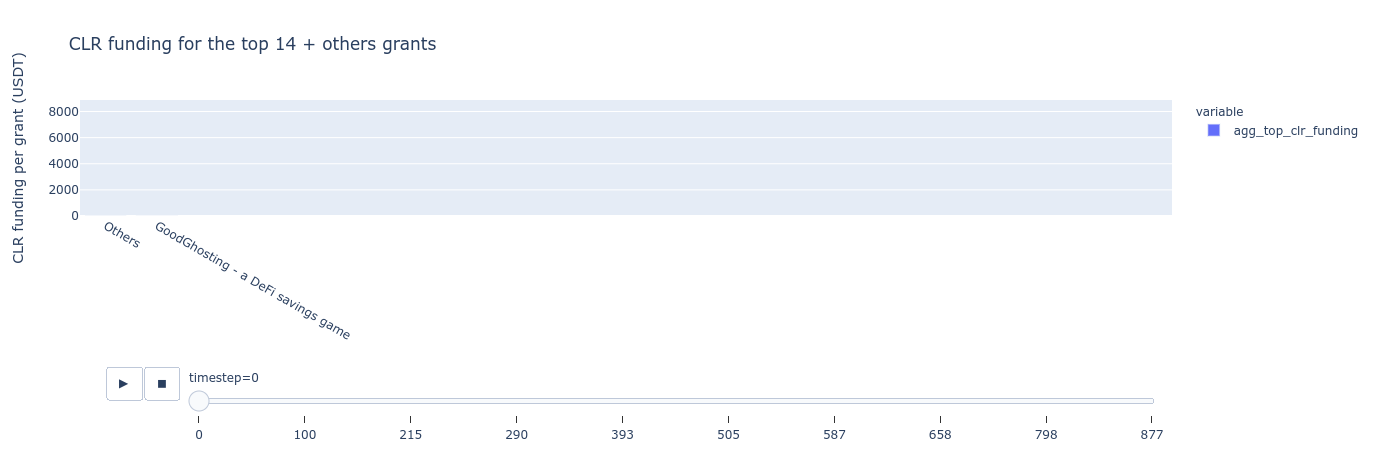

time: 345 ms


In [11]:
key = 'agg_top_clr_funding'
fig_df = (grant_dfs[key]
          .sort_values(by=key))


t_col = 'timestep'
N_points = 10
t = fig_df[t_col].unique()
f = int(len(t) / N_points)
sampled_timesteps = t[::f]
fig_df = (fig_df.set_index(t_col)
                .loc[sampled_timesteps]
                .reset_index()
                .sort_values(by=[t_col, key]))

title = 'CLR funding for the top 14 + others grants'

x_col = 'grant'
y_cols = [key]

labels = {'value': 'CLR funding per grant (USDT)',
          'grant': ''}

options = {'x': x_col,
           'y': y_cols,
           'title': title,
           'labels': labels,
           'animation_frame': t_col,
           'range_x': [-0.5, len(fig_df[x_col].unique()) * 0.8],
           'range_y': [0, int(fig_df[y_cols].max()) * 1.1]}

fig = px.bar(fig_df, **options)
fig['layout']['updatemenus'][0]['pad']=dict(r=10,t=150)
fig['layout']['sliders'][0]['pad']=dict(r=10,t=150)
fig.show()

#### Grant donations

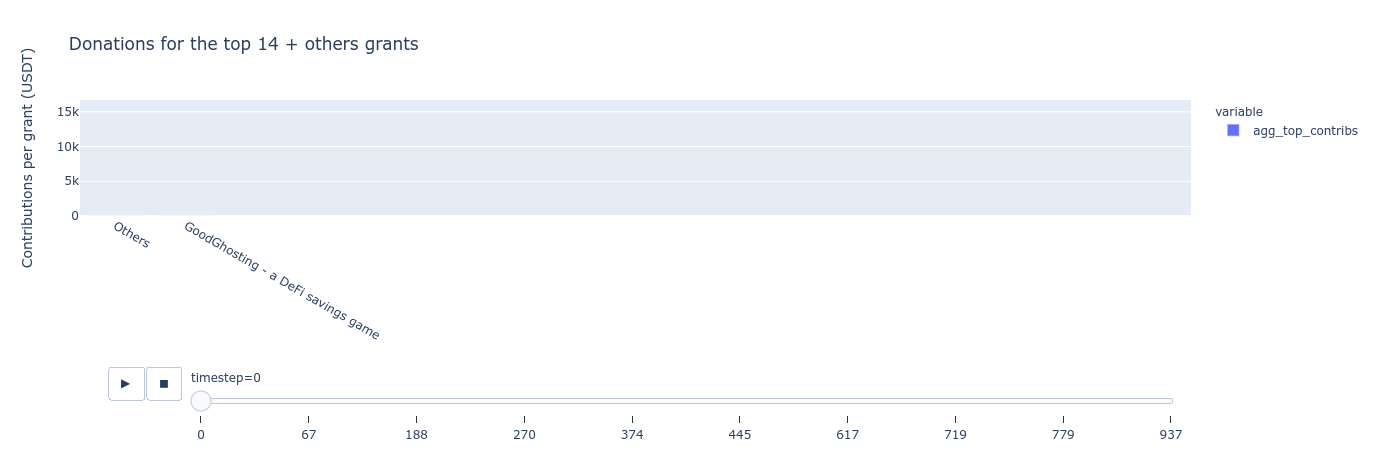

time: 293 ms


In [12]:


key = 'agg_top_contribs'
fig_df = (grant_dfs[key]
          .sort_values(by=key))

t_col = 'timestep'
N_points = 10
t = fig_df[t_col].unique()
f = int(len(t) / N_points)
sampled_timesteps = t[::f]
fig_df = (fig_df.set_index(t_col)
                .loc[sampled_timesteps]
                .reset_index()
                .sort_values(by=[t_col, key]))

title = 'Donations for the top 14 + others grants'


x_col = 'grant'
y_cols = [key]

labels = {'value': 'Contributions per grant (USDT)',
          'grant': ''}

options = {'x': x_col,
           'y': y_cols,
           'title': title,
           'labels': labels,
           'animation_frame': t_col,
           'range_x': [-0.5, len(fig_df[x_col].unique()) * 0.8],
           'range_y': [0, int(fig_df[y_cols].max()) * 1.1]}

fig = px.bar(fig_df, **options)
fig['layout']['updatemenus'][0]['pad']=dict(r=10,t=150)
fig['layout']['sliders'][0]['pad']=dict(r=10,t=150)
fig.show()

#### Grant unique collaborators

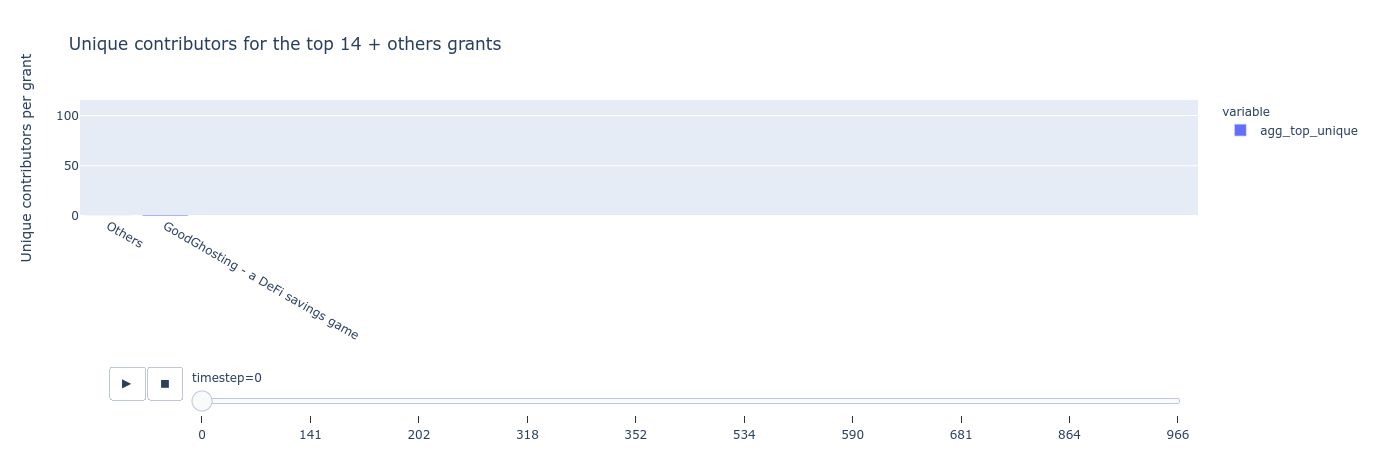

time: 302 ms


In [13]:
key = 'agg_top_unique'
fig_df = (grant_dfs[key]
          .sort_values(by=key))

t_col = 'timestep'
N_points = 10
t = fig_df[t_col].unique()
f = int(len(t) / N_points)
sampled_timesteps = t[::f]
fig_df = (fig_df.set_index(t_col)
                .loc[sampled_timesteps]
                .reset_index()
                .sort_values(by=[t_col, key]))

title = 'Unique contributors for the top 14 + others grants'

x_col = 'grant'
y_cols = [key]

labels = {'value': 'Unique contributors per grant',
          'grant': ''}

options = {'x': x_col,
           'y': y_cols,
           'title': title,
           'labels': labels,
           'animation_frame': t_col,
           'range_x': [-0.5, len(fig_df[x_col].unique()) * 0.8],
           'range_y': [0, int(fig_df[y_cols].max()) * 1.1]}

fig = px.bar(fig_df, **options)
fig['layout']['updatemenus'][0]['pad']=dict(r=10, t=150)
fig['layout']['sliders'][0]['pad']=dict(r=10, t=150)
fig.show()

## Conclusions